# Witches Project

**Authors:** Elsa Bidant (elsa.bidant@psl.eu), Éloïse Delerue (eloise.delerue@psl.eu)

**Date:** May 2026

## 1. Library Import

In [ ]:
# Data manipulation and analytics
import pandas as pd
import numpy as np

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# JAX and NumPyro for Bayesian modeling
import jax.numpy as jnp
import jax

# PyMC for Bayesian modeling
import pymc as pm

# Post-sampling analysis and diagnostics
import arviz as az

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Data Import

In [27]:
df_witches = pd.read_csv('WDB_Accused.csv')
pd.set_option('display.max_columns', None)

In [28]:
df_case = pd.read_csv('WDB_Case.csv')

In [29]:
df = df_case.merge(df_witches, on="AccusedRef", how="inner")
df

,index_x,CaseRef,CaseId,CaseSystemId,NamedIndividual,AccusedRef,CaseStart_date,CaseStart_date_as_date,Case_date,Case_date_as_date,Age_at_case,CaseCommonName,Commission,Complaint,Correspondence,Chronicle,Other,Suspects_text,UNorthodoxRelPract_p,UNorthodoxRelPract_s,Consulting_p,Consulting_s,Demonic_p,Demonic_s,Demonic_possess_p,Demonic_possess_s,Fairies_p,Fairies_s,Folk_healing_p,Folk_healing_s,Maleficium_p,Maleficium_s,Midwifery_p,Midwifery_s,ImplicatedByAnother_p,ImplicatedByAnother_s,Neighbhd_dispute_p,Neighbhd_dispute_s,PoliticalMotive_p,PoliticalMotive_s,PropertyMotive_p,PropertyMotive_s,RefusedCharity_p,RefusedCharity_s,Treason_p,Treason_s,Other_p,Other_s,OtherText,NotEnoughInfo_p,NotEnoughInfo_s,WhiteMagic_p,WhiteMagic_s,Charnotes,DemonicPact,DevilNotes,WitchesMeeting,MeetingName,DevilPresent,Maleficium,CommunalSex,DevilWorship,FoodAndDrink,Dancing,Singing,SingingText,OtherPractices,MeetingNotes,Elphane/Fairyland,Food/Drink,SpecificVerbalFormulae,SpecificRitualActs,Familiars,Shape-Changing,Dreams/Visions,UnorthodoxReligiousPractice,SympatheticMagic,Ridingdead,FolkNotes,HumanIllness,HumanDeath,AnimalIllness,AnimalDeath,FemaleInfertility,MaleImpotence,AggravatingDisease,TransferringDisease,LayingOn,Removalbewitchment,Quarreling,Cursing,Poisoning,RecHealer,HealingHumans,HealingAnimals,Midwifery,DiseaseNotes,PropertyDamage,WeatherModification,OtherMaleficiaNotes,OtherChargesNotes,ClaimedBewitched,ClaimedPossessed,AdmitLesserCharge,ClaimedNaturalCauses,Nodefence,DefenseNotes,CaseNotes,Createdby_x,Createdate_x,Lastupdatedby_x,Lastupdatedon_x,index_y,AccusedSystemId,AccusedID,FirstName,LastName,M_Firstname,M_Surname,Alias,Patronymic,DesTitle,Sex,Age,Age_estcareer,Age_estchild,Res_settlement,Res_parish,Res_presbytery,Res_county,Res_burgh,Res_NGR_Letters,Res_NGR_Easting,Res_NGR_Northing,Ethnic_origin,MaritalStatus,SocioecStatus,Occupation,Notes,Createdby_y,Createdate_y,Lastupdatedby_y,Lastupdatedon_y
0,1,C/EGD/100,100,EGD,-1.0,A/EGD/89,27/1/1591,01/27/91 00:00:00,8/5/1591,05/08/91 00:00:00,NaN,"Kerington,Cristine",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1,0,0,Part of the North Berwick witch hunt. It invo...,0,Said by others to have met the devil as a 'mek...,0,NaN,0,0,0,0,0,0,0,NaN,NaN,See Agnes Sampson's case for description of No...,0,0,0,0,0,0,0,0,0,0,In other accused's confession it was said that...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,SMD,05/15/01 17:00:16,jhm,10/10/02 14:51:54,2264,EGD,89,Cristine,Kerington,Christine,Carrington,Lukit,NaN,NaN,Female,NaN,0,0,NaN,NaN,NaN,Haddington,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SMD,05/15/01 11:06:51,jhm,09/18/02 15:21:25
1,2,C/EGD/1000,1000,EGD,-1.0,A/EGD/989,6/5/1627,05/06/27 00:00:00,6/5/1627,05/06/27 00:00:00,NaN,"Craig,Christiane",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1,0,0,NaN,0,NaN,0,NaN,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,SMD,05/15/01 17:00:16,jhm,10/09/02 15:52:09,2369,EGD,989,Christiane,Craig,Christine,Craig,NaN,NaN,NaN,Female,NaN,0,0,NaN,P/ST/1538,Turriff,Aberdeen,NaN,NaN,NaN,NaN,NaN,Married,NaN,NaN,Husband also accused of Witchcraft.,SMD,05/15/01 11:06:51,jhm,10/01/02 10:01:18
2,3,C/EGD/1001,1001,EGD,-1.0,A/EGD/990,NaN,NaN,25/4/1627,04/25/27 00:00:00,NaN,"Ronaldson,Margaret",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1,0,0,NaN,0,NaN,0,NaN,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,SMD,05/15/01 17:00:16,jhm,09/18/02 15:23:08,2371,EGD,990,Margaret,Ronaldson,Margaret,Ronaldson,NaN,NaN,NaN,Female,NaN,0,0,NaN,P/ST/421,Aberdeen,Aberdeen,Aberdeen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SMD,05/15/01 11:06:51,jhm,09/18/02 15:23:08
3,4,C/EGD/1002,1002,EGD,-1.0,A/EGD/991,NaN,NaN,3/5/1627,05/03/27 00:00:00,NaN,"Broun,Bessie",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0

## 3. Data Manipulation

In [30]:
# Transform categorical variables into dummy variables
df_encoded = pd.get_dummies(df, columns=[
    "Sex",
    "MaritalStatus",
    "SocioecStatus"
], drop_first=True)

# Transform True/False values into 1/0
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [31]:
# Selecting the variables used in the model
variables = [col for col in df_encoded.columns 
             if col.startswith("Sex_") 
             or col.startswith("MaritalStatus_") 
             or col == "Age"]

df_encoded = df_encoded.dropna(subset=variables + ["Demonic_s"]) # Drop NaN values in the selected variables

X = df_encoded[variables]
y = df_encoded["Demonic_s"].values
X

,Age,Sex_Male,MaritalStatus_Irregular union,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
17,50.0,0,0,0,0,0
26,42.0,0,0,0,0,0
30,43.0,0,0,1,0,0
35,25.0,0,0,0,0,0
36,50.0,0,0,1,0,0
...,...,...,...,...,...,...
2751,50.0,0,0,0,0,0
2857,50.0,0,0,0,0,0
2868,14.0,1,0,0,0,0
2877,30.0,0,0,0,0,0


## 4. Data Description

In [32]:
df['Age'] = df['Age'].apply(lambda x: x if np.isnan(x) else int(x))

Text(0, 0.5, 'Number of Trials')

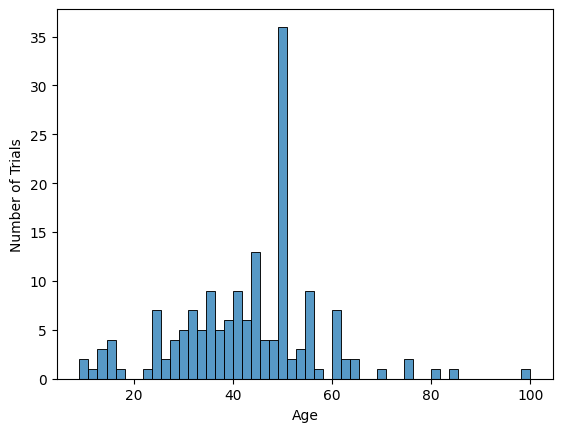

In [33]:
sns.histplot(df_encoded['Age'], bins=50)
plt.gca().set_xlabel("Age")
plt.gca().set_ylabel("Number of Trials")

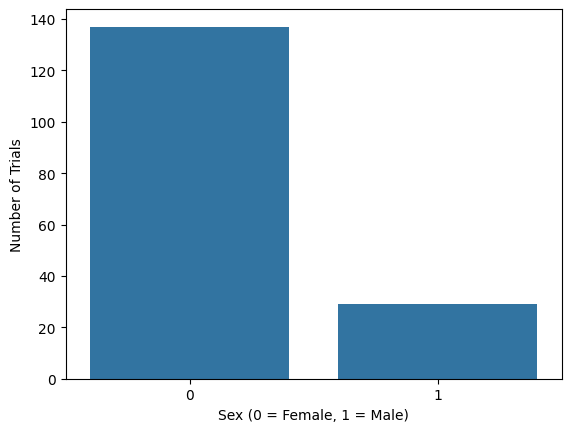

In [ ]:
counts = df_encoded['Sex_Male'].value_counts()
sns.barplot(x = counts.index, y = counts.values)
plt.gca().set_xlabel("Sex (0 = Female, 1 = Male)")
plt.gca().set_ylabel("Number of Trials")
plt.show()

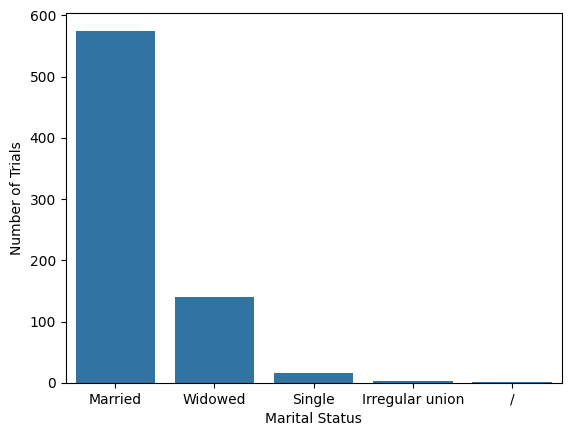

In [ ]:
counts = df['MaritalStatus'].value_counts()
sns.barplot(x = counts.index, y = counts.values)
plt.gca().set_xlabel("Marital Status")
plt.gca().set_ylabel("Number of Trials")
plt.show()

## 5. Linear Model

In [36]:
# Data standardization
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [37]:
n_features = X.shape[1]

with pm.Model() as model:
    
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=1, shape=n_features)
    intercept = pm.Normal("intercept", mu=0, sigma=1)
    
    # Logit
    logit_p = intercept + pm.math.dot(X, beta)
    
    # Likelihood
    y_obs = pm.Bernoulli("y_obs", logit_p=logit_p, observed=y)
    
    # Sampling
    trace = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=1,
        target_accept=0.9
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [beta, intercept]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 352 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


array([[<Axes: title={'center': 'beta\nAge'}>,
        <Axes: title={'center': 'beta\nSex_Male'}>,
        <Axes: title={'center': 'beta\nMaritalStatus_Irregular union'}>],
       [<Axes: title={'center': 'beta\nMaritalStatus_Married'}>,
        <Axes: title={'center': 'beta\nMaritalStatus_Single'}>,
        <Axes: title={'center': 'beta\nMaritalStatus_Widowed'}>],
       [<Axes: title={'center': 'intercept'}>, <Axes: >, <Axes: >]],
      dtype=object)

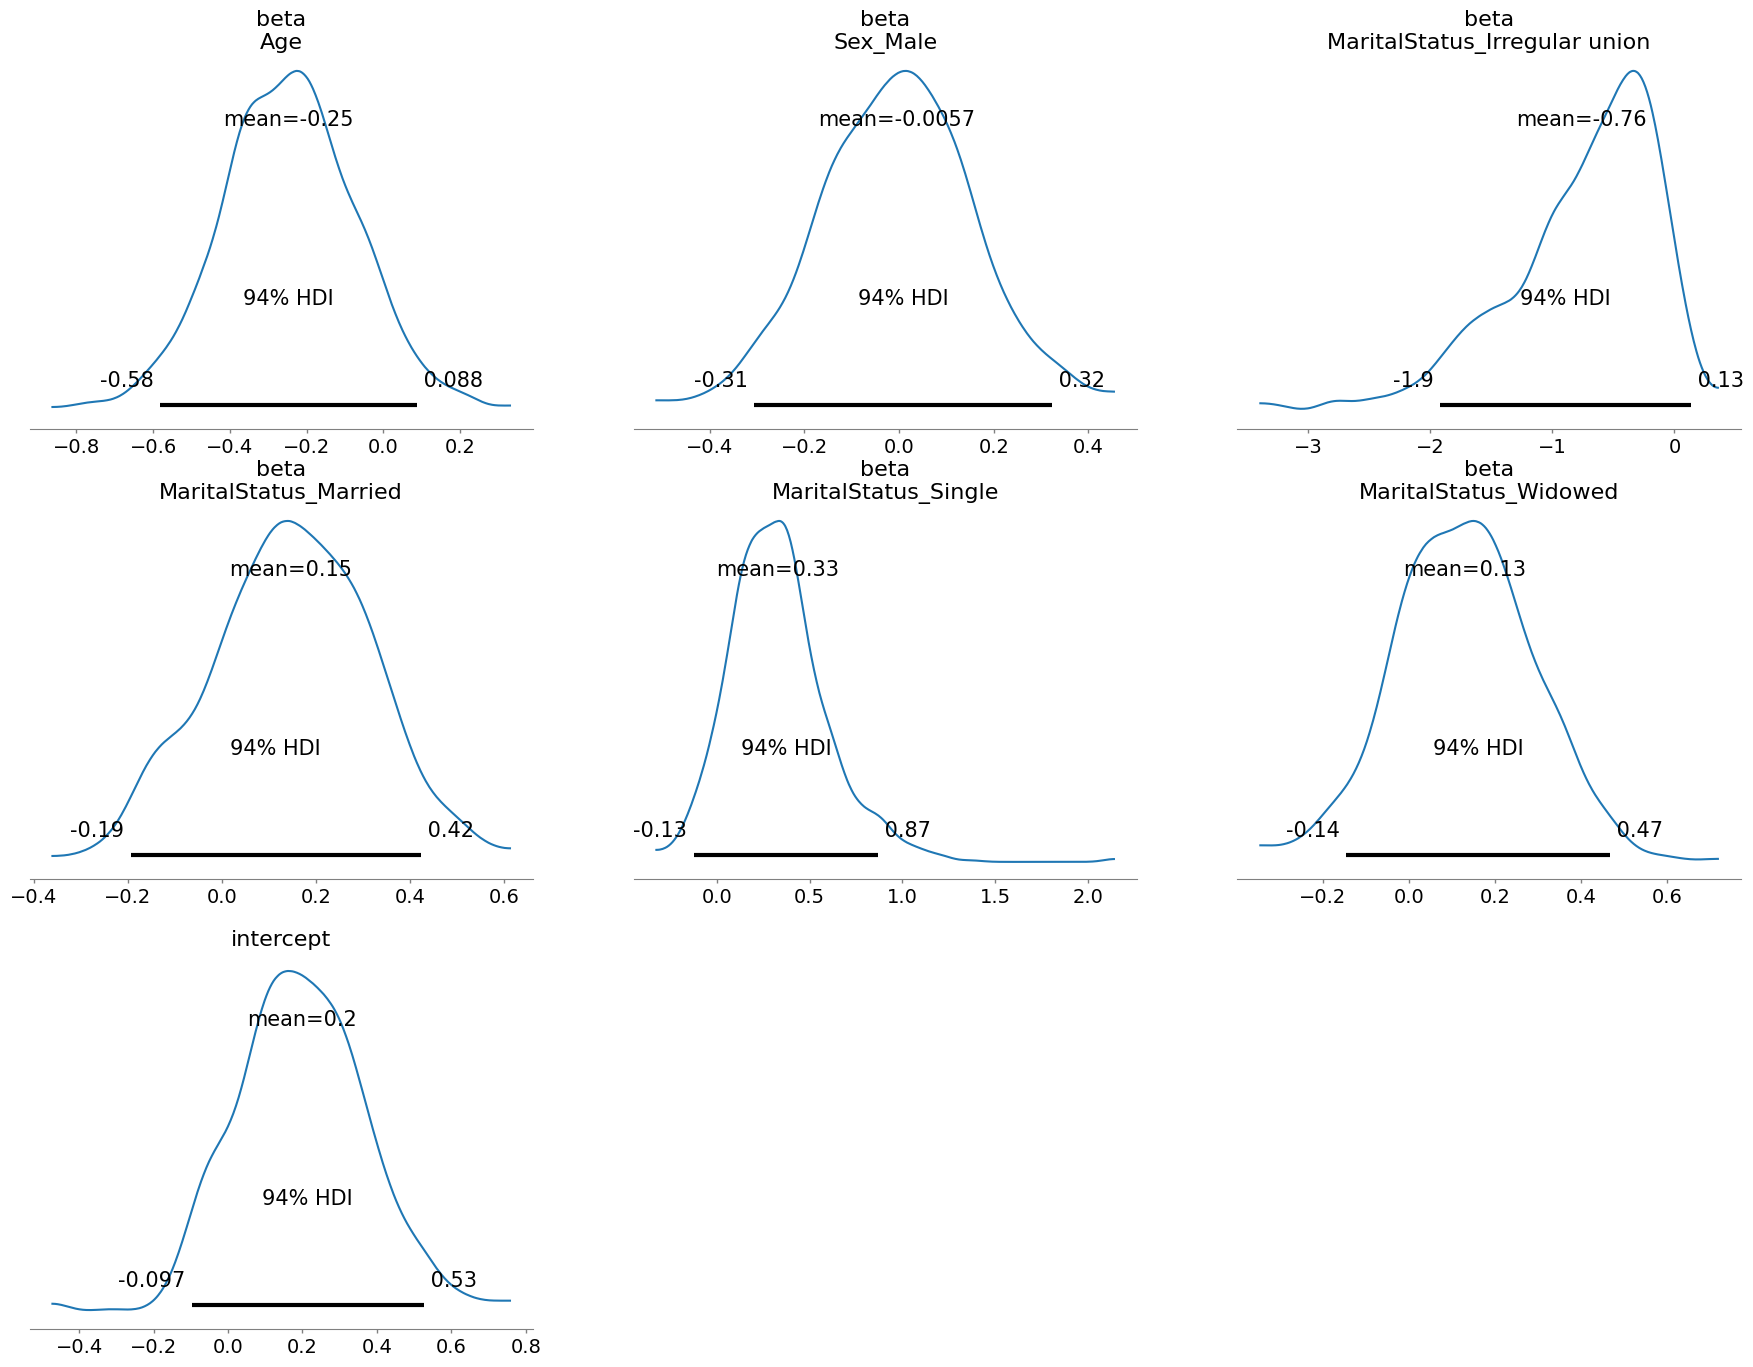

In [ ]:
feature_names = df_encoded[variables].columns.tolist()

idata = trace

beta_dims = idata.posterior["beta"].dims
dim_name = idata.posterior["beta"].dims[-1]

idata.posterior = idata.posterior.assign_coords(
    {dim_name: feature_names}
)

az.plot_posterior(idata, var_names=["beta", "intercept"])

In [40]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[Age],-0.247,0.178,-0.581,0.088,0.006,0.006,762.0,682.0,1.01
beta[Sex_Male],-0.006,0.164,-0.306,0.323,0.006,0.005,806.0,773.0,1.00
beta[MaritalStatus_Irregular union],-0.758,0.621,-1.920,0.132,0.026,0.026,758.0,721.0,1.00
beta[MaritalStatus_Married],0.147,0.168,-0.193,0.423,0.006,0.005,696.0,652.0,1.00
beta[MaritalStatus_Single],0.327,0.264,-0.125,0.870,0.010,0.012,822.0,464.0,1.00
beta[MaritalStatus_Widowed],0.129,0.161,-0.145,0.466,0.005,0.005,937.0,656.0,1.00
intercept,0.197,0.173,-0.097,0.525,0.006,0.006,906.0,900.0,1.00
